In [1]:
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
test_dir="/content/drive/MyDrive/Tumour/test"
train_dir="/content/drive/MyDrive/Tumour/train"
valid_dir="/content/drive/MyDrive/Tumour/valid"

In [ ]:
! pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.7 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is in

In [3]:
import os
import matplotlib.pyplot as pt
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report,confusion_matrix

In [5]:
#Data Augumentation for train data
train_gen=ImageDataGenerator(rescale=1.0/255,
                                 rotation_range=20,# Random rotation between -20 to +20 degree rotation
                                 width_shift_range=0.2,# Random horizontal shift between ±20% of width
                                 height_shift_range=0.2,# Random vertical shift by ±20% of height
                             zoom_range=0.2,# Random zoom between 80% and 120%
                                 horizontal_flip=True,# Random horizontal flipping
                                 vertical_flip=False,#No vertical flipping (can enable if appropiate
                                 fill_mode='nearest'# Strategy for filling in newly created pixels))
)

# validation and test generators(only rescaling ,no augmentation)
validate_gen=ImageDataGenerator(rescale=1.0/255)
test_gen=ImageDataGenerator(rescale=1.0/255)

In [6]:
# image size and batch size
img_width,img_height=224,224 #Adjust as need
batch_size=32 #Ajust as need

#Create data generator
train_generator=train_gen.flow_from_directory(train_dir,
                                              target_size=(img_width,img_height),
                                              batch_size=batch_size,
                                              class_mode='categorical' # or 'binary' if you have 2 classes)
)

validate_generator=validate_gen.flow_from_directory(valid_dir,
                                                    target_size=(img_width,img_height),
                                                    batch_size=batch_size,
                                                    class_mode='categorical'
)
test_generator=test_gen.flow_from_directory(test_dir,
                                                    target_size=(img_width,img_height),
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                            shuffle=False # Important for evaluating the test set
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


In [7]:
class_names=list(train_generator.class_indices.keys())
num_classes=len(class_names)
print(f"class names: {class_names}")
print(f"Number of classes: {num_classes}")

class names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [8]:
# Build simple CNN model

model=models.Sequential([layers.Conv2D(32,(3,3),activation='relu',input_shape=(img_height,img_width,3)),
                          layers.MaxPooling2D((2,2)),

                          layers.Conv2D(64,(3,3),activation='relu'),
                          layers.MaxPool2D((2,2)),

                          layers.Conv2D(128,(3,3),activation='relu'),
                          layers.MaxPool2D((2,2)),

                          layers.Flatten(),
                          layers.Dense(128,activation='relu'),
                          layers.Dense(num_classes,activation='softmax')

                                        ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy',
              tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

#Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
epochs=10
history=model.fit(train_generator,
                  steps_per_epoch=train_generator.samples//batch_size,
                  epochs=epochs,
                  validation_data=validate_generator,
                  validation_steps=validate_generator.samples//batch_size)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 690s 13s/step - accuracy: 0.3744 - loss: 1.3966 - precision: 0.4517 - recall: 0.1149 - val_accuracy: 0.5792 - val_loss: 0.9767 - val_precision: 0.7273 - val_recall: 0.3167
Epoch 2/10
 1/52 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6250 - loss: 0.9839 - precision: 0.8125 - recall: 0.4062

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.6250 - loss: 0.9839 - precision: 0.8125 - recall: 0.4062 - val_accuracy: 0.5562 - val_loss: 0.9853 - val_precision: 0.7978 - val_recall: 0.2958
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 595ms/step - accuracy: 0.6142 - loss: 0.9595 - precision: 0.7412 - recall: 0.3749 - val_accuracy: 0.5813 - val_loss: 0.9844 - val_precision: 0.6553 - val_recall: 0.4792
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7500 - loss: 0.7221 - precision: 0.7500 - recall: 0.6562 - val_accuracy: 0.5917 - val_loss: 0.9759 - val_precision: 0.6657 - val_recall: 0.4812
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 593ms/step - accuracy: 0.6695 - loss: 0.8333 - precision: 0.7401 - recall: 0.5452 - val_accuracy: 0.6167 - val_loss: 0.9101 - val_precision: 0.6778 - val_recall: 0.5083
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5312 - loss: 1.1932 - precision: 0.6071 - recall: 0.5312 - val_accuracy: 0.6750 - val_loss: 0.8132 - val

In [11]:
import pickle
with open('/content/drive/MyDrive/Tumour/CNNmodel.pkl','wb')as file:
  pickle.dump(history,file)

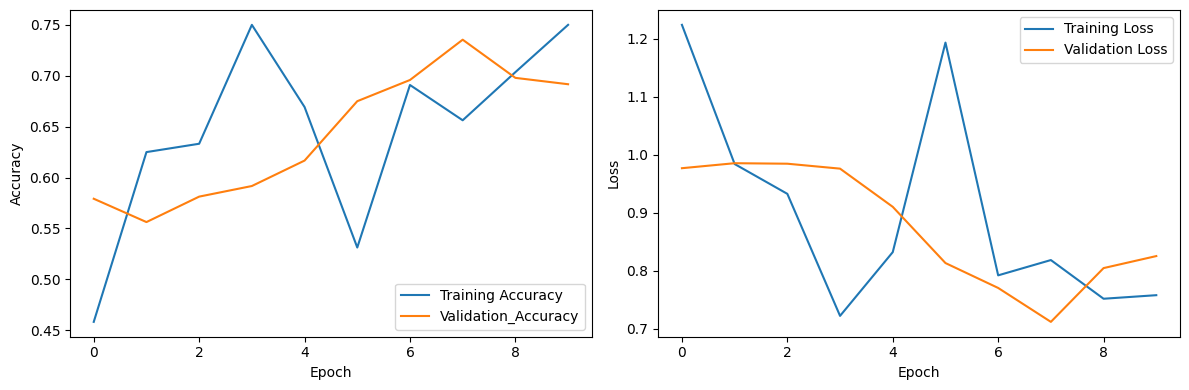

In [12]:
def plot_history(history):
  pt.figure(figsize=(12,4))
  pt.subplot(1,2,1)
  pt.plot(history.history['accuracy'],label='Training Accuracy')
  pt.plot(history.history['val_accuracy'],label='Validation_Accuracy')
  pt.xlabel('Epoch')
  pt.ylabel('Accuracy')
  pt.legend()

  pt.subplot(1,2,2)
  pt.plot(history.history['loss'],label='Training Loss')
  pt.plot(history.history['val_loss'],label='Validation Loss')
  pt.xlabel('Epoch')
  pt.ylabel('Loss')
  pt.legend()

  pt.tight_layout()
  pt.show()
plot_history(history)


In [13]:
# Evaluate on test set
test_loss,test_acc,test_precision,test_recall=model.evaluate(test_generator)
print(f"\n Test accuracy: {test_acc:.4f}")
print(f"\n Test precision: {test_precision:.4f}")
print(f"\n Test accuracy: {test_recall:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 69s 10s/step - accuracy: 0.7064 - loss: 0.8120 - precision: 0.7405 - recall: 0.6742

 Test accuracy: 0.6870

 Test precision: 0.7265

 Test accuracy: 0.6585


In [14]:
# Generate predictions()

import numpy as np

test_generator.reset()
predictions=model.predict(test_generator,steps=test_generator.samples // batch_size+1)
predicted_classes=np.argmax(predictions,axis=1)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step


In [15]:

# Get true classes
true_classes=test_generator.classes

In [16]:
# classification report

print("\n classification report:")
print(classification_report(true_classes,predicted_classes,target_names=class_names))

# confusion matrix
con_matrix=confusion_matrix(true_classes,predicted_classes)
print(con_matrix)




 classification report:
              precision    recall  f1-score   support

      glioma       0.68      0.93      0.78        80
  meningioma       1.00      0.02      0.03        63
    no_tumor       0.81      0.88      0.84        49
   pituitary       0.61      0.94      0.74        54

    accuracy                           0.69       246
   macro avg       0.78      0.69      0.60       246
weighted avg       0.77      0.69      0.59       246

[[74  0  1  5]
 [30  1  9 23]
 [ 2  0 43  4]
 [ 3  0  0 51]]


In [22]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import (VGG16, ResNet50, MobileNet,
                                          InceptionV3, EfficientNetB0)
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D,Dropout

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping




# Results storage
model_comparison = []


In [23]:
# VGG16 evaluation

def evaluate_vgg16():
  base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))
  base_model.trainable=False

  model=tf.keras.Sequential([
      base_model,
      GlobalAveragePooling2D(),
      Dropout(0.2),
      Dense(num_classes,activation='softmax')
  ])

  model.compile(optimizer=Adam(0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy',
                         tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall')]

  )

  history=model.fit(train_generator,
                    validation_data=validate_generator,
                    epochs=10,
                    callbacks=[EarlyStopping(patience=3)]
                    )
  return model,history

vgg_model,vgg_history=evaluate_vgg16()
model_comparison.append({
    'Model': 'VGG16',
    'Val Accuracy': max(vgg_history.history['val_accuracy']),
    'Val Precision': max(vgg_history.history['val_precision']),
    'Val Recall': max(vgg_history.history['val_recall']),
    'Parameters': f"{vgg_model.count_params(): ,}",
    'Inference': 'Medium',
    'Best For': 'Medium sized Datasets'})

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.3004 - loss: 1.4129 - precision: 0.2628 - recall: 0.0054 - val_accuracy: 0.5279 - val_loss: 1.2454 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 655ms/step - accuracy: 0.4866 - loss: 1.2431 - precision: 0.8660 - recall: 0.0707 - val_accuracy: 0.5538 - val_loss: 1.1248 - val_precision: 0.8070 - val_recall: 0.1833
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 640ms/step - accuracy: 0.5439 - loss: 1.1253 - precision: 0.8025 - recall: 0.2038 - val_accuracy: 0.6275 - val_loss: 1.0431 - val_precision: 0.7660 - val_recall: 0.2151
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 690ms/step - accuracy: 0.5814 - loss: 1.0448 - precision: 0.7929 - recall: 0.2584 - val_accuracy: 0.6434 - val_loss: 0.9790 - val_precision: 0.7836 - val_recall: 0.2669
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 645ms/step - accuracy: 0.6195 - loss: 0.9850 - precision: 

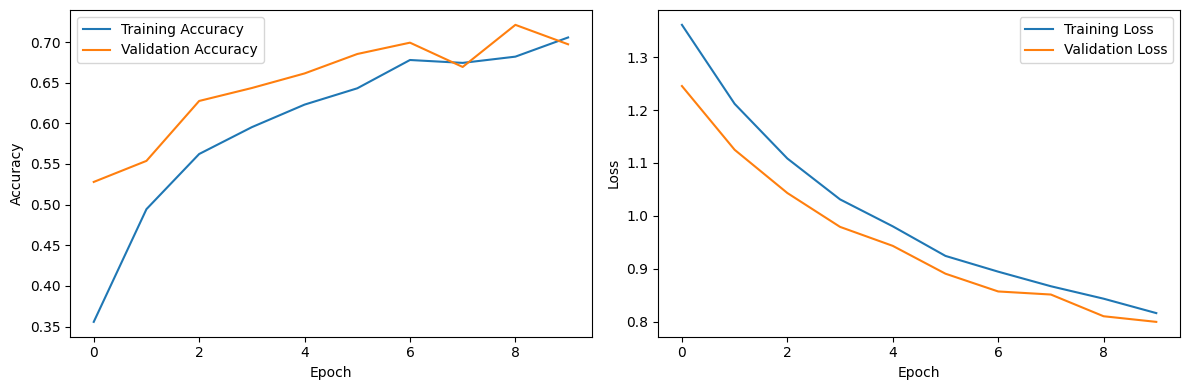

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.7159 - loss: 0.7483 - precision: 0.8702 - recall: 0.5500

Test accuracy: 0.7154
Test precision: 0.8630
Test recall: 0.5122
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step


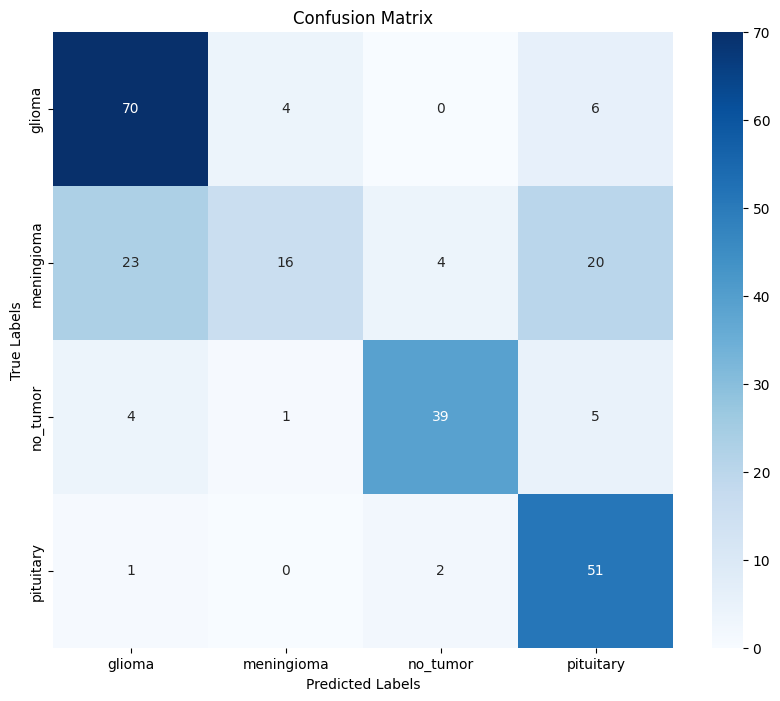

In [24]:
import matplotlib.pyplot as pt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_history(history):
  pt.figure(figsize=(12,4))
  pt.subplot(1,2,1)

  pt.plot(history.history['accuracy'],label='Training Accuracy')
  pt.plot(history.history['val_accuracy'],label='Validation Accuracy')
  pt.xlabel('Epoch')
  pt.ylabel('Accuracy')
  pt.legend()

  pt.subplot(1,2,2)

  pt.plot(history.history['loss'],label='Training Loss')
  pt.plot(history.history['val_loss'],label='Validation Loss')
  pt.xlabel('Epoch')
  pt.ylabel('Loss')
  pt.legend()

  pt.tight_layout()
  pt.show()
plot_history(vgg_history)

# Evaluate on test set (assuming you have a test_generator)
test_generator.reset() # Reset the generator before evaluating
test_loss, test_acc, test_precision, test_recall = vgg_model.evaluate(test_generator)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test precision: {test_precision:.4f}')
print(f'Test recall: {test_recall:.4f}')

# Generate predictions
predictions = vgg_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get true classes
true_classes = test_generator.classes

# Confusion Matrix
conf_mat = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix using seaborn
pt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
pt.xlabel('Predicted Labels')
pt.ylabel('True Labels')
pt.title('Confusion Matrix')
pt.show()



In [27]:
#ResNet50 Evaluation


def evaluate_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy', 'precision', 'recall'])

    history = model.fit(
        train_generator,
        validation_data=validate_generator,
        epochs=10,
        callbacks=[EarlyStopping(patience=3)]
    )

    return model, history

resnet_model, resnet_history = evaluate_resnet50()
model_comparison.append({
    'Model': 'ResNet50',
    'Val Accuracy': max(resnet_history.history['val_accuracy']),
    'Val Precision': max(resnet_history.history['val_precision']),
    'Val Recall': max(resnet_history.history['val_recall']),
    'Parameters': f"{resnet_model.count_params():,}",
    'Inference Time': 'Medium',
    'Best For': 'General purpose'
})

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 904ms/step - accuracy: 0.2677 - loss: 1.4963 - precision: 0.2680 - recall: 0.0459 - val_accuracy: 0.4243 - val_loss: 1.2666 - val_precision: 0.8276 - val_recall: 0.0478
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 595ms/step - accuracy: 0.3950 - loss: 1.3060 - precision: 0.6966 - recall: 0.0529 - val_accuracy: 0.5398 - val_loss: 1.2209 - val_precision: 0.8286 - val_recall: 0.0578
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 593ms/step - accuracy: 0.4234 - loss: 1.2539 - precision: 0.7301 - recall: 0.0832 - val_accuracy: 0.5438 - val_loss: 1.1728 - val_precision: 0.8605 - val_recall: 0.0737
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 602ms/step - accuracy: 0.4331 - loss: 1.2234 - precision: 0.7356 - recall: 0.0928 - val_accuracy: 0.5598 - val_loss: 1.1682 - val_precision: 0.8222 - val_recall: 0.0737
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 609ms/step - accuracy: 0.4603 - loss: 1.2403 - precision: 0.7091 - recall: 0.1056 - val_accuracy: 0.5518 - val_los

In [29]:
# MobileNetEvaluation

def evaluate_mobilenet():
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy', 'precision', 'recall'])

    history = model.fit(
        train_generator,
        validation_data=validate_generator,
        epochs=10,
        callbacks=[EarlyStopping(patience=3)]
    )

    return model, history

mobilenet_model, mobilenet_history = evaluate_mobilenet()
model_comparison.append({
    'Model': 'MobileNet',
    'Val Accuracy': max(mobilenet_history.history['val_accuracy']),
    'Val Precision': max(mobilenet_history.history['val_precision']),
    'Val Recall': max(mobilenet_history.history['val_recall']),
    'Parameters': f"{mobilenet_model.count_params():,}",
    'Inference Time': 'Fast',
    'Best For': 'Mobile/Edge devices'
})


Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4025 - loss: 1.5163 - precision: 0.4429 - recall: 0.2830 - val_accuracy: 0.7789 - val_loss: 0.6000 - val_precision: 0.8607 - val_recall: 0.6892
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 590ms/step - accuracy: 0.7511 - loss: 0.6341 - precision: 0.8186 - recall: 0.6654 - val_accuracy: 0.8406 - val_loss: 0.4443 - val_precision: 0.8879 - val_recall: 0.7888
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 587ms/step - accuracy: 0.8131 - loss: 0.4827 - precision: 0.8578 - recall: 0.7654 - val_accuracy: 0.8606 - val_loss: 0.3839 - val_precision: 0.8980 - val_recall: 0.8247
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 634ms/step - accuracy: 0.8583 - loss: 0.3978 - precision: 0.8966 - recall: 0.8128 - val_accuracy: 0.8705 - val_loss: 0.3649 - val_precision: 0.9077 - val_recall: 0.8426
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 584ms/step - accuracy: 0.8574 - loss: 0.3717 - precision: 0.8780 - recall: 0.8215 - val_accuracy: 0.8327 - val_loss: 

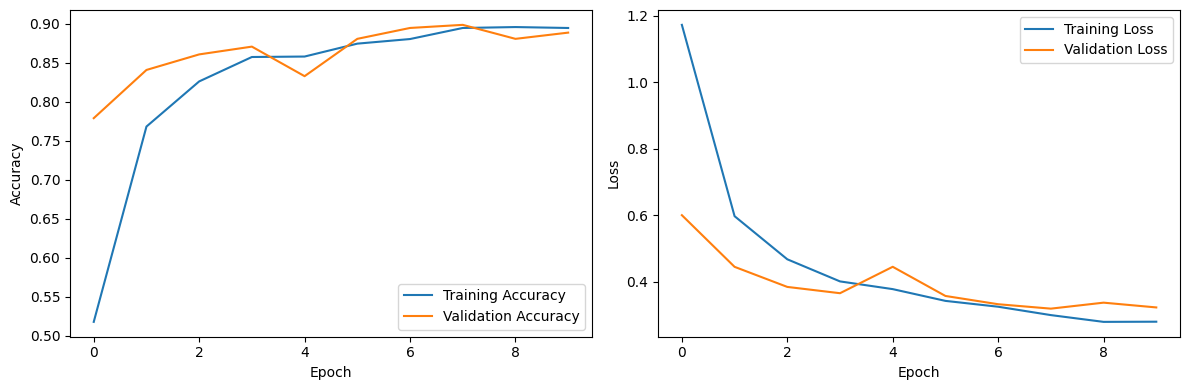

In [30]:
# plot History of mobilenet

plot_history(mobilenet_history)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.8850 - loss: 0.3333 - precision: 0.9041 - recall: 0.8688

MobileNet Test accuracy: 0.8699
MobileNet Test precision: 0.8979
MobileNet Test recall: 0.8577


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 608ms/step


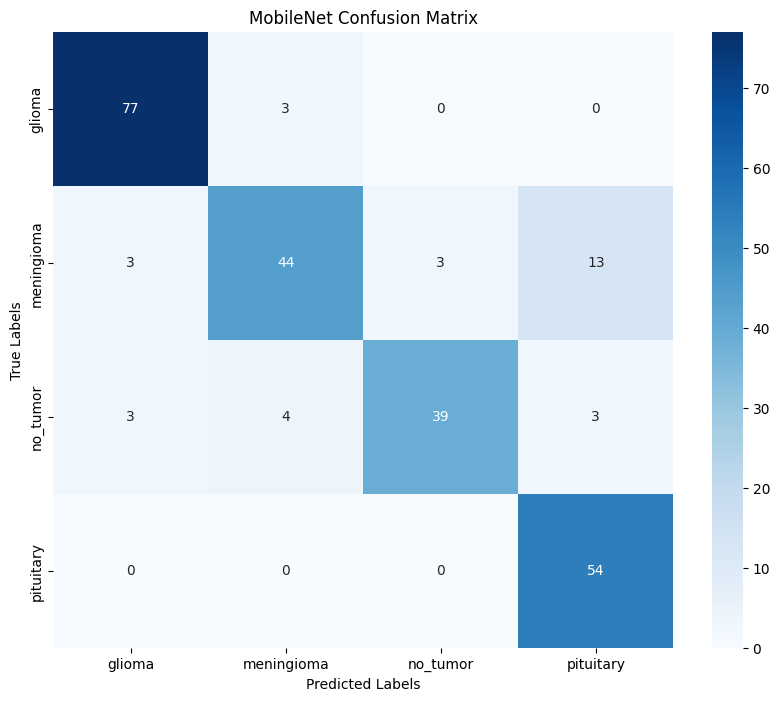

In [31]:
# Evaluation on test set using MobileNet

test_generator.reset()  # Reset the generator before evaluating
test_loss, test_acc, test_precision, test_recall = mobilenet_model.evaluate(test_generator)
print(f'\nMobileNet Test accuracy: {test_acc:.4f}')
print(f'MobileNet Test precision: {test_precision:.4f}')
print(f'MobileNet Test recall: {test_recall:.4f}')

# Generate predictions for MobileNet
predictions = mobilenet_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get true classes for MobileNet
true_classes = test_generator.classes

# Confusion Matrix for MobileNet
conf_mat = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix for MobileNet using seaborn
pt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
pt.xlabel('Predicted Labels')
pt.ylabel('True Labels')
pt.title('MobileNet Confusion Matrix')
pt.show()

In [35]:
def evaluate_inception():
    # Special generator for Inception's 299x299 input
    inception_train_gen = train_gen.flow_from_directory(
        train_dir, target_size=(299, 299), batch_size=batch_size)
    inception_val_gen = validate_gen.flow_from_directory(
        valid_dir, target_size=(299, 299), batch_size=batch_size)

    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(299, 299, 3))
    x = tf.keras.applications.inception_v3.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy', 'precision', 'recall'])

    history = model.fit(
        inception_train_gen,
        validation_data=inception_val_gen,
        epochs=10,
        callbacks=[EarlyStopping(patience=3)]
    )

    return model, history

inception_model, inception_history = evaluate_inception()
model_comparison.append({
    'Model': 'InceptionV3',
    'Val Accuracy': max(inception_history.history['val_accuracy']),
    'Val Precision': max(inception_history.history['val_precision']),
    'Val Recall': max(inception_history.history['val_recall']),
    'Parameters': f"{inception_model.count_params():,}",
    'Inference Time': 'Medium',
    'Best For': 'Multi-scale features'
})

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.3597 - loss: 1.3298 - precision: 0.4843 - recall: 0.0440 - val_accuracy: 0.4323 - val_loss: 1.2255 - val_precision: 0.6200 - val_recall: 0.1235
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 956ms/step - accuracy: 0.4490 - loss: 1.2244 - precision: 0.6945 - recall: 0.1416 - val_accuracy: 0.3546 - val_loss: 1.2591 - val_precision: 0.5000 - val_recall: 0.3167
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 975ms/step - accuracy: 0.4586 - loss: 1.1986 - precision: 0.6427 - recall: 0.2052 - val_accuracy: 0.5896 - val_loss: 1.0827 - val_precision: 0.7874 - val_recall: 0.1992
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 976ms/step - accuracy: 0.5426 - loss: 1.1254 - precision: 0.7705 - recall: 0.2108 - val_accuracy: 0.4920 - val_loss: 1.1022 - val_precision: 0.6806 - val_recall: 0.2590
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 50s 943ms/step - accuracy: 0.5646 - loss: 1.0968 - precision: 0.7219 - recall: 0.2231 - val_accuracy: 0.5498 - val_loss:

In [36]:
# EfficientNetB0 Evaluation
def evaluate_efficientnet():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy', 'precision', 'recall'])

    history = model.fit(
        train_generator,
        validation_data=validate_generator,
        epochs=10,
        callbacks=[EarlyStopping(patience=3)]
    )

    return model, history

efficientnet_model, efficientnet_history = evaluate_efficientnet()
model_comparison.append({
    'Model': 'EfficientNetB0',
    'Val Accuracy': max(efficientnet_history.history['val_accuracy']),
    'Val Precision': max(efficientnet_history.history['val_precision']),
    'Val Recall': max(efficientnet_history.history['val_recall']),
    'Parameters': f"{efficientnet_model.count_params():,}",
    'Inference Time': 'Fast',
    'Best For': 'Best accuracy/efficiency tradeoff'
})

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.2799 - loss: 1.4019 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3207 - val_loss: 1.3918 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 607ms/step - accuracy: 0.3255 - loss: 1.3826 - precision: 0.0679 - recall: 1.2409e-04 - val_accuracy: 0.3207 - val_loss: 1.3909 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 604ms/step - accuracy: 0.2995 - loss: 1.3713 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3207 - val_loss: 1.3817 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 591ms/step - accuracy: 0.3192 - loss: 1.3776 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3207 - val_loss: 1.3984 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 616ms/

In [37]:
# Results comparison

comparison_df = pd.DataFrame(model_comparison)
comparison_df = comparison_df.sort_values('Val Accuracy', ascending=False)
comparison_df.style.background_gradient(cmap='Blues', subset=['Val Accuracy', 'Val Precision', 'Val Recall'])

,Model,Val Accuracy,Val Precision,Val Recall,Parameters,Inference,Best For,Inference Time
2,MobileNet,0.898406,0.918067,0.878486,"3,232,964",nan,Mobile/Edge devices,Fast
0,VGG16,0.721116,0.818627,0.482072,"14,716,740",Medium,Medium sized Datasets,nan
3,InceptionV3,0.649402,0.796610,0.388446,"21,810,980",nan,Multi-scale features,Medium
1,ResNet50,0.637450,0.860465,0.201195,"23,595,908",nan,General purpose,Medium
4,EfficientNetB0,0.320717,0.000000,0.000000,"4,054,695",nan,Best accuracy/efficiency tradeoff,Fast


In [38]:
comparison_df.to_csv('/content/drive/MyDrive/model_comparison.csv', index=False)

In [39]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/model_comparison.csv')
df

,Model,Val Accuracy,Val Precision,Val Recall,Parameters,Inference,Best For,Inference Time
0,MobileNet,0.898406,0.918067,0.878486,"3,232,964",NaN,Mobile/Edge devices,Fast
1,VGG16,0.721116,0.818627,0.482072,"14,716,740",Medium,Medium sized Datasets,NaN
2,InceptionV3,0.649402,0.796610,0.388446,"21,810,980",NaN,Multi-scale features,Medium
3,ResNet50,0.637450,0.860465,0.201195,"23,595,908",NaN,General purpose,Medium
4,EfficientNetB0,0.320717,0.000000,0.000000,"4,054,695",NaN,Best accuracy/efficiency tradeoff,Fast


The best performing model is:
Model                       MobileNet
Val Accuracy                 0.898406
Val Precision                0.918067
Val Recall                   0.878486
Parameters                  3,232,964
Inference                         NaN
Best For          Mobile/Edge devices
Inference Time                   Fast
Name: 0, dtype: object


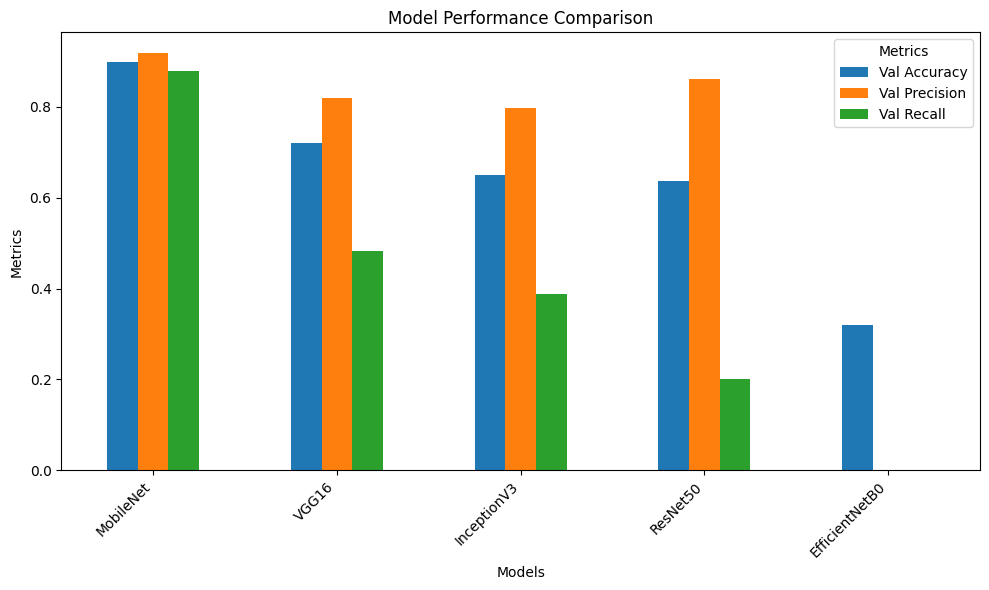

In [40]:
# Find the best model

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/model_comparison.csv')


# Find the best model based on validation accuracy
best_model = df.loc[df['Val Accuracy'].idxmax()]

print(f"The best performing model is:\n{best_model}")

# Plotting the bar chart
plt.figure(figsize=(10, 6))
df.plot(x='Model', y=['Val Accuracy', 'Val Precision', 'Val Recall'], kind='bar', ax=plt.gca())
plt.title('Model Performance Comparison')
plt.ylabel('Metrics')
plt.xlabel('Models')


plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

In [41]:
mobilenet_model.save('/content/drive/MyDrive/mobilenet_model.h5')

In [45]:
!pip install streamlit numpy pillow tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.8 MB/s eta 0:00:00


In [46]:
#Streamlit APP


import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
import os


TUMOR_CLASSES=['glioma', 'meningioma', 'no_tumor', 'pituitary']

# Load stom trained model
@st.cache_resource
def load_custom_model():
    model_path = '/content/drive/MyDrive/mobilenet_model.h5'
    if not os.path.exists(model_path):
        st.error(f"Model file not found at {model_path}")
        return None
    return load_model(model_path)

model = load_custom_model()

# Streamlit app
st.title("🎣 Brain Tumor Classifier")
st.write(f"Upload a brain tumor image to classify")

# File uploader
uploaded_file = st.file_uploader("Choose a brain image...",
                                type=["jpg", "jpeg", "png"])

if uploaded_file is not None and model is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_column_width=True)

    # Preprocess the image
    image = image.resize((224, 224))  # Match your model's expected input
    image_array = img_to_array(image)
    image_array = image_array / 255.0  # Normalize (if your model expects this)
    image_array = np.expand_dims(image_array, axis=0)

    # Make prediction
    with st.spinner('Identifying tumor classes...'):
        predictions = model.predict(image_array)
        predicted_class = TUMOR_CLASSES[np.argmax(predictions)]
        confidence = np.max(predictions)

    # Display results
    st.subheader("Prediction Results:")
    st.success(f"Species: {predicted_class}")
    st.info(f"Confidence: {confidence*100:.2f}%")

    # Show all class probabilities
    st.subheader("All Class Probabilities:")
    for i, (cls, prob) in enumerate(zip(TUMOR_CLASSES, predictions[0])):
        st.write(f"{cls}: {prob*100:.2f}%")
        st.progress(float(prob))


2026-03-03 12:30:38.417 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:30:43.900 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:30:46.335 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-03 12:30:46.344 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:30:46.346 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:30:46.352 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:30:46.354 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn